In [7]:
%autoreload 2

In [2]:
%reload_ext autoreload

import numpy as np
import pandas as pd
import seaborn as sns
import sys, os, shutil
sys.path.append(r'C://Users//Zichen//anaconda3//envs//2ptank//Lib//site-packages//')
from fish import Gafftopsail, Coelacanth
import behavior_finder as bhfd
import utils
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap

pink = "#FB008C"
green = "#72D100"
cmap_conv = LinearSegmentedColormap.from_list("conv",[green, (1, 1, 1), pink])
cmap_conj = cm.get_cmap('coolwarm_r')

plt.rcParams.update({'font.size': 6})

C:\Users\Zichen\AppData\Local\Temp\ipykernel_23480\671254359.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_conj = cm.get_cmap('coolwarm_r')


__GET RELEVANT BEHAVIOR DATA__

In [4]:
path = r"C:\Data\Imaging\260425_overlap\All_behavior//"
all_df = []
all_saccade_df = []
thetas = [f'theta_{seg}' for seg in range(0, 13)]
fishlist = [
 r"C:\Data\Imaging\260415_overlap\fish3",r"C:\Data\Imaging\260415_overlap\fish3_2",
r"C:\Data\Imaging\260415_overlap\fish4", r"C:\Data\Imaging\260415_overlap\fish4_2",
     r"C:\Data\Imaging\260415_overlap\fish6", r"C:\Data\Imaging\260415_overlap\fish6_2",
r"C:\Data\Imaging\260425_overlap\fish1", r"C:\Data\Imaging\260425_overlap\fish1_2",
r"C:\Data\Imaging\260425_overlap\fish2",r"C:\Data\Imaging\260425_overlap\fish2_2",
r"C:\Data\Imaging\260425_overlap\fish3",r"C:\Data\Imaging\260425_overlap\fish3_2",
r"C:\Data\Imaging\260425_overlap\fish5",r"C:\Data\Imaging\260425_overlap\fish5_2",
 r"C:\Data\Imaging\260425_overlap\fish6", r"C:\Data\Imaging\260425_overlap\fish6_2",
r"C:\Data\Imaging\260425_overlap\fish7",r"C:\Data\Imaging\260425_overlap\fish7_2",
r"C:\Data\Imaging\260425_overlap\fish8",r"C:\Data\Imaging\260425_overlap\fish8_2",
r"C:\Data\Imaging\260425_overlap\fish9", r"C:\Data\Imaging\260425_overlap\fish9_2",
     r"C:\Data\Imaging\260425_overlap\fish10", r"C:\Data\Imaging\260425_overlap\fish10_2",
r"C:\Data\Imaging\260425_overlap\fish11", r"C:\Data\Imaging\260425_overlap\fish11_2",
]
for f in fishlist:
    bout_df = pd.read_csv(f + '//Tail//tail_bout_df.csv', index_col=0, converters={'cont_tuples_tailindex': utils.parse_int_tuple, 'cont_tuples_realtime_s': utils.parse_float_tuple, 'tail_angle': float})
        # "cont_tuples_tailindex": lambda x: try: (int(x.split('(')[2].split(')')[0]), int(x.split('(')[3].split(')')[0])) except IndexError:(int(x.split('(')[2].split(')')[0]), int(x.split('(')[3].split(')')[0])),
        # "cont_tuples_realtime_s":lambda x: (float(x.split('(')[2].split(')')[0]), float(x.split('(')[3].split(')')[0])),
        # "tail_angle": float})
    saccade_df = pd.read_csv(f + '//eye//proofread_eye_saccade_df.csv', index_col = 0,converters={
                                         "cont_tuples_eyeindex": lambda x: (int(x.split('(')[1].split(',')[0]),
                                                                            int(x.split(',')[1].split(')')[0])),
                                         "cont_tuples_realtime_s": lambda x: (float(x.split('(')[1].split(',')[0]),
                                                                              float(x.split(',')[1].split(')')[0])),
                                     })
    bout_df.loc[:, "fish_id"] = f
    saccade_df.loc[:, 'fish_id'] = f
    all_df.append(bout_df)
    all_saccade_df.append(saccade_df)

all_df = pd.concat(all_df).reset_index(drop = True)
all_saccade_df = pd.concat(all_saccade_df).reset_index(drop = True)

stimulus_df = Gafftopsail(f + '//', filelist = ['stimulus']).stimulus_df
#stimulus_df =Coelacanth(f + '//', filelist = ['stimulus']).stimulus_df
stimulus_df.loc[:, "stim_name"] = [str(s) for s in stimulus_df.stim_name]

#for overlap fishes
omr_stim = [i for i in stimulus_df.stim_name.unique() if ('[' not in i) and ('dot' not in i) and ('pause' not in i)]
dot_stim = [i for i in stimulus_df.stim_name.unique() if ('[' not in i) and ('dot' in i) and ('pause' not in i)]
overlap_stim = [i for i in stimulus_df.stim_name.unique() if ('dot' in i) & ('[' in i)]
stimlists = [omr_stim, dot_stim, overlap_stim]
#for dot fish
# stimlists = [['dot_l_3', 'dot_r_3'],['dot_l_5', 'dot_r_5'],['dot_l_10', 'dot_r_10'], ['dot_l_20', 'dot_r_20'],['dot_l_40', 'dot_r_40']]

In [5]:
#for each bout, asslign the closest saccade and
max_diff_s = 5
all_diffs = []
all_convs = []
all_conjs = []
for fish in all_df.fish_id.unique():
    fish_bout_df = all_df[all_df.fish_id == fish]
    fish_saccade_df = all_saccade_df[all_saccade_df.fish_id == fish]
    bout_start_s = [float(i[0]) for i in fish_bout_df.cont_tuples_realtime_s]
    saccade_start_s = [float(i[0]) for i in fish_saccade_df.cont_tuples_realtime_s]
    diffs = [np.subtract(bs, saccade_start_s) for bs in bout_start_s]#positive: saccade -> bout, negative: bout-> saccade
    nearest_saccade_s = [diff[np.argmin(np.abs(diff))] for diff in diffs]
    nearest_saccade_s = [i if np.abs(i) <= max_diff_s else np.nan for i in nearest_saccade_s]
    nearest_saccade_conv = [fish_saccade_df['e_conv_change'].iloc[np.argmin(np.abs(diff))] for diff in diffs]
    nearest_saccade_conj = [fish_saccade_df['e_conj_change'].iloc[np.argmin(np.abs(diff))] for diff in diffs]
    all_diffs.extend(nearest_saccade_s)
    all_convs.extend(nearest_saccade_conv)
    all_conjs.extend(nearest_saccade_conj)
all_df.loc[:, 'nearest_saccade_s'] = all_diffs
all_df.loc[:, 'nearest_saccade_conv'] = all_convs
all_df.loc[:, 'nearest_saccade_conj'] = all_conjs

__BASIC CHARACTERIZATION__

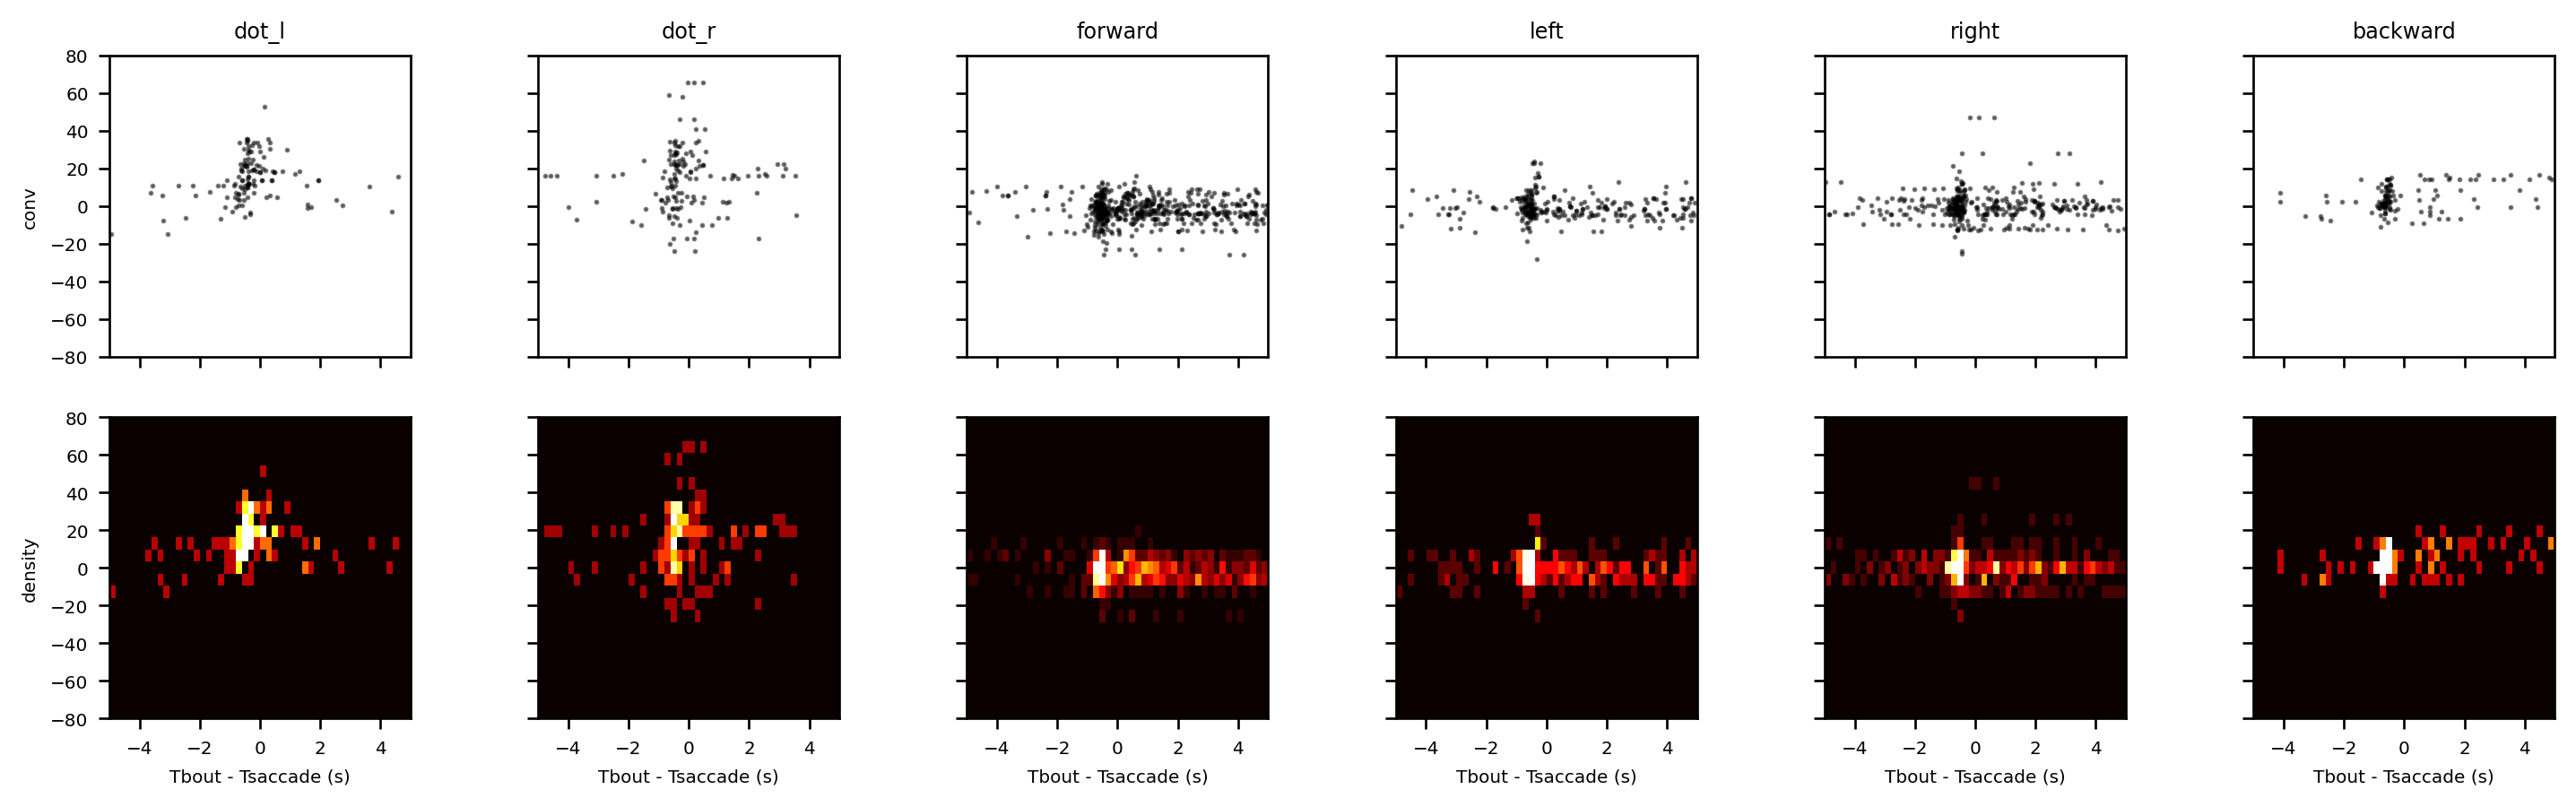

In [6]:
def plot_nearest_saccade(stims, all_df, bystim = True):
    #see if the bout is close to a saccade
    fig, ax = plt.subplots(2, len(stims), dpi=240, figsize=(15, 4), sharex=True, sharey='row')

    stims = [str(i) for i in stims]
    for n, stim in enumerate(stims):
        if bystim:
            stim_bout_df = all_df[all_df.tail_realstimuli == stim]
        else:
            stim_bout_df = all_df[all_df.bout_type == stim]
        x = stim_bout_df.nearest_saccade_s.values
        y = stim_bout_df.nearest_saccade_conv.values
        # Top row: scatter
        ax[0, n].scatter(x, y, s=0.5,color='black',alpha=0.5)
        ax[0, n].set_ylim([-80, 80])
        ax[0, n].set_xlim([-5, 5])
        ax[0, n].set_title(stim)

        # Bottom row: density heatmap
        H, xedges, yedges = np.histogram2d(x,y,bins=[50, 25],range=[[-5, 5], [-80, 80]])
        # convert to percentage
        H = H / H.sum() * 100
        im = ax[1, n].imshow(H.T, origin='lower', aspect='auto', extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], cmap='hot', vmin=0, vmax=3)
        ax[1, n].set_ylim([-80, 80])
        ax[1, n].set_xlim([-5, 5])
        ax[0, n].set_box_aspect(1)
        ax[1, n].set_box_aspect(1)

    # labels
    ax[0, 0].set_ylabel('conv')
    ax[1, 0].set_ylabel('density')
    for a in ax[1]:
        a.set_xlabel('Tbout - Tsaccade (s)')
    return fig
stims = ['dot_l', 'dot_r', 'forward', 'left', 'right', 'backward']#[['dot_l', 'forward'], ['dot_r', 'forward'], ['dot_l', 'left'], ['dot_r', 'left'], ['dot_l', 'right'], ['dot_r', 'right'], ['dot_l', 'backward'], ['dot_r', 'backward']]#['dot_l', 'dot_r', 'forward', 'left', 'right', 'backward']
plot_nearest_saccade(stims, all_df)
plt.savefig(path + 'nearest_saccade_vergence.svg')
plt.show()
plt.close()

(0.415686, 0.352941, 0.803922, 1.0) <class 'tuple'>
(0.78, 0.08, 0.52, 1.0) <class 'tuple'>
(0.7000000000000001, 1.0, 0.3999999999999999, 1.0) <class 'tuple'>
(0.3999999999999999, 0.9999999999999999, 1.0, 1.0) <class 'tuple'>
(1.0, 0.3999999999999999, 0.3999999999999999, 1.0) <class 'tuple'>
(0.6999999999999997, 0.3999999999999999, 1.0, 1.0) <class 'tuple'>


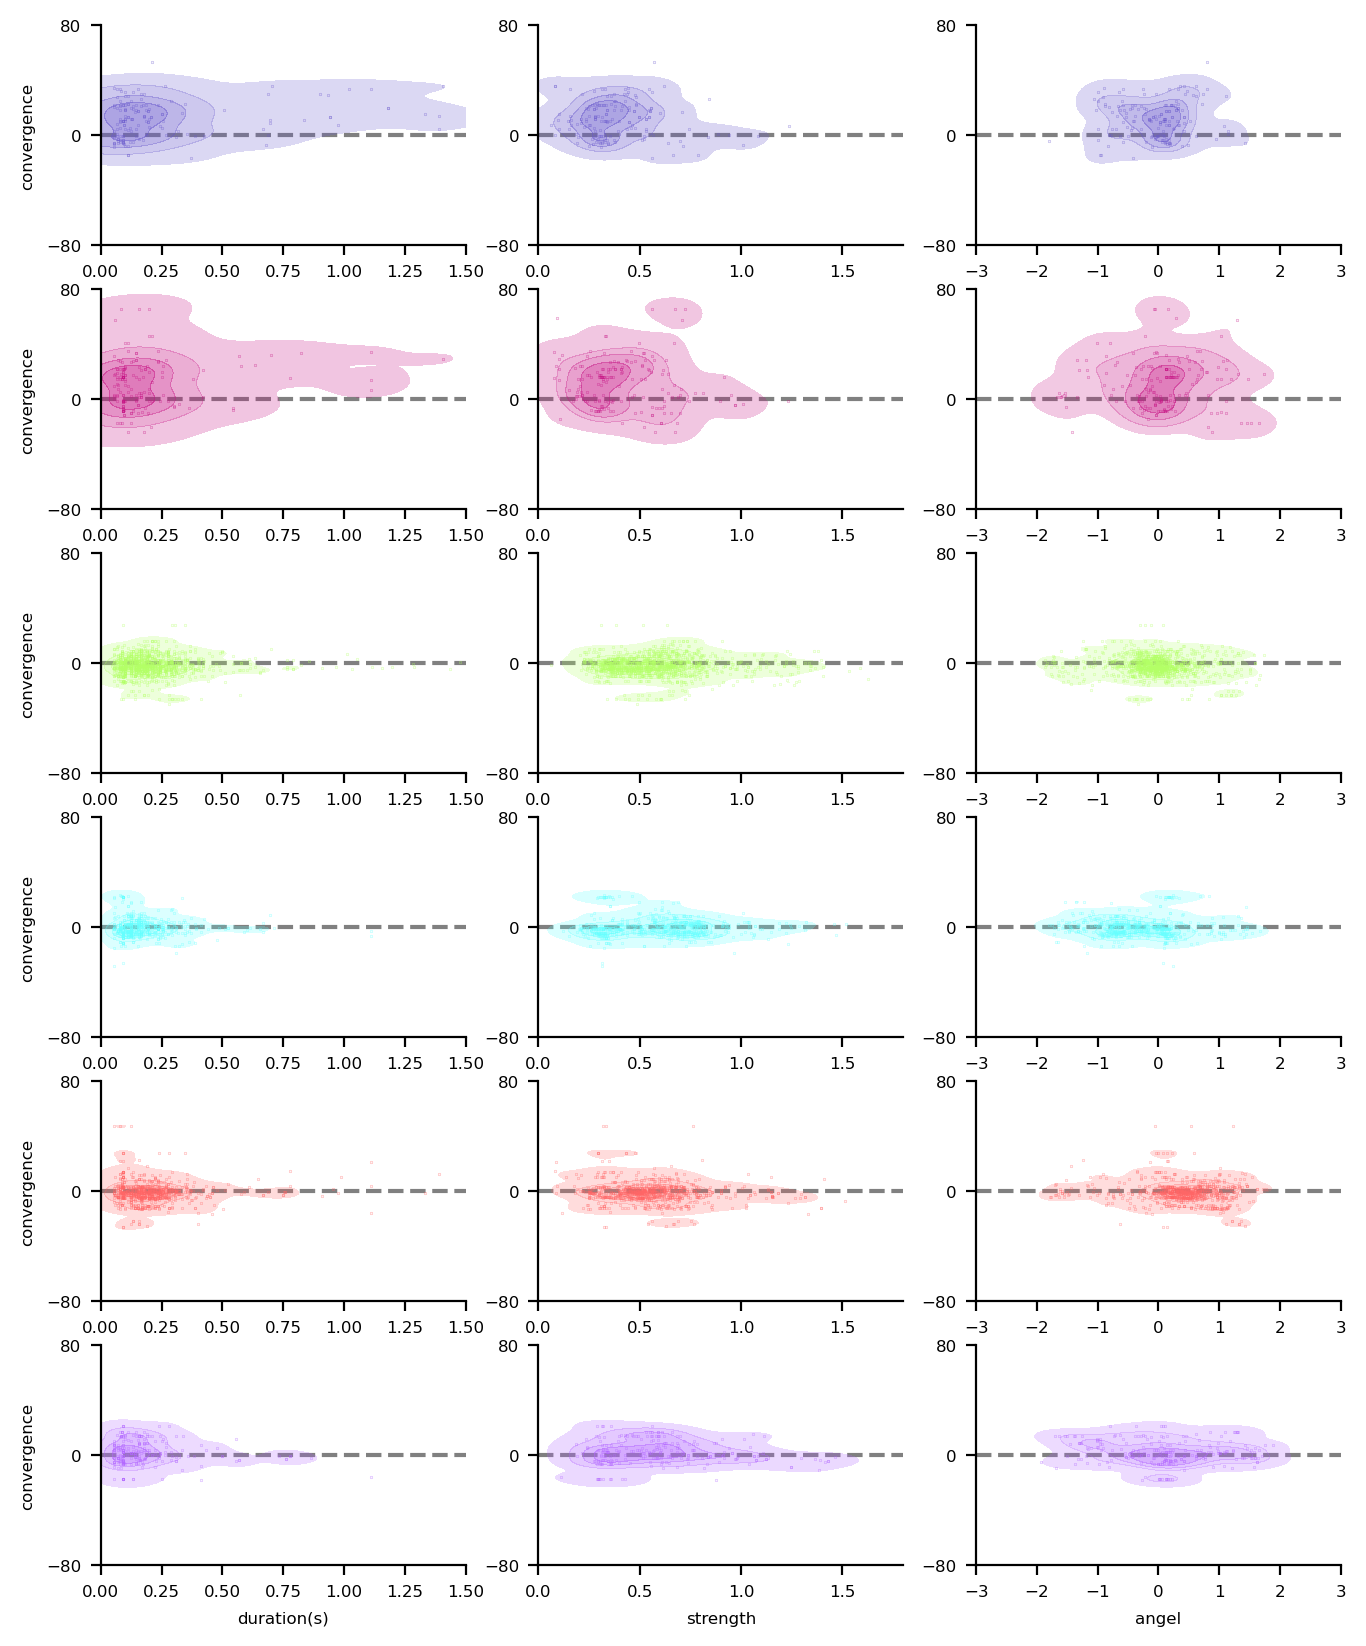

In [7]:
import matplotlib.colors as mcolors

def plot_feature_distribution(stimlist, all_df, bystim = True):
    fig, ax = plt.subplots(len(stimlist), 3, figsize = (8, 10), dpi = 200)
    for n, stim in enumerate(stimlist):
        if bystim:
            df_interest = all_df[all_df.tail_realstimuli == stim]
            stim_color = mcolors.to_rgba(utils.stim_colors[stim])
        else:
            df_interest = all_df[all_df.bout_type == stim]
            stim_color_dict = {'L': utils.stim_colors['left'], 'R': utils.stim_colors['right'], 'H': tuple(utils.pink), 'dot': tuple(utils.pink), 'grating': tuple(utils.green)}
            stim_color = stim_color_dict[stim]
        custom_cmap = LinearSegmentedColormap.from_list( 'stim_cmap', [(*stim_color[:3], 0.2), (*stim_color[:3], 0.6) ])
        print(stim_color, type(stim_color))
        ax[n, 0].scatter(df_interest.tail_duration_s, df_interest.nearest_saccade_conv, s = .01, color = stim_color, alpha = 1)
        sns.kdeplot(x=df_interest.tail_duration_s, y=df_interest.nearest_saccade_conv, fill=True, cmap=custom_cmap, levels=5, ax=ax[n, 0])

        ax[n, 1].scatter(df_interest.tail_strength, df_interest.nearest_saccade_conv, s = .01, color= stim_color, alpha = 1)
        sns.kdeplot(x=df_interest.tail_strength, y=df_interest.nearest_saccade_conv, fill=True, cmap=custom_cmap, levels=5, ax=ax[n, 1])

        ax[n, 2].scatter(df_interest.tail_angle, df_interest.nearest_saccade_conv, s = .01, color= stim_color, alpha = 1)
        sns.kdeplot(x=df_interest.tail_angle, y=df_interest.nearest_saccade_conv, fill=True, cmap=custom_cmap, levels=5, ax=ax[n, 2])

        ax[n, 0].set_xlabel('duration(s)')
        ax[n, 0].set_ylabel('convergence')
        ax[n, 1].set_xlabel('strength')
        ax[n, 1].set_ylabel('')
        ax[n, 2].set_ylabel('')
        ax[n, 2].set_xlabel('angel')
        ax[n, 0].set_xlim([0, 1.5])
        ax[n, 1].set_xlim([0, 1.8])
        ax[n, 2].set_xlim([-3, 3])
    for axis in ax.flatten():
        axis.set_ylim([-80, 80])
        axis.set_yticks([-80, 0, 80])
        axis.spines[['top', 'right']].set_visible(False)
        axis.axhline(0, color='grey', linestyle='--', zorder = -1)
    return fig
stimlist = ['dot_l', 'dot_r', 'forward', 'left', 'right', 'backward']
plot_feature_distribution(stimlist, all_df)
plt.savefig(path + 'tail_features.png')
plt.show()
plt.close()

Intersection(s) at x = [-24.7118054  -22.85560001 -20.75190058 -14.31705526   9.44237364
  47.68020451  50.031398  ]
Intersection(s) at x = [-24.7118054  -22.85560001 -20.75190058 -14.31705526   9.44237364
  47.68020451  50.031398  ]


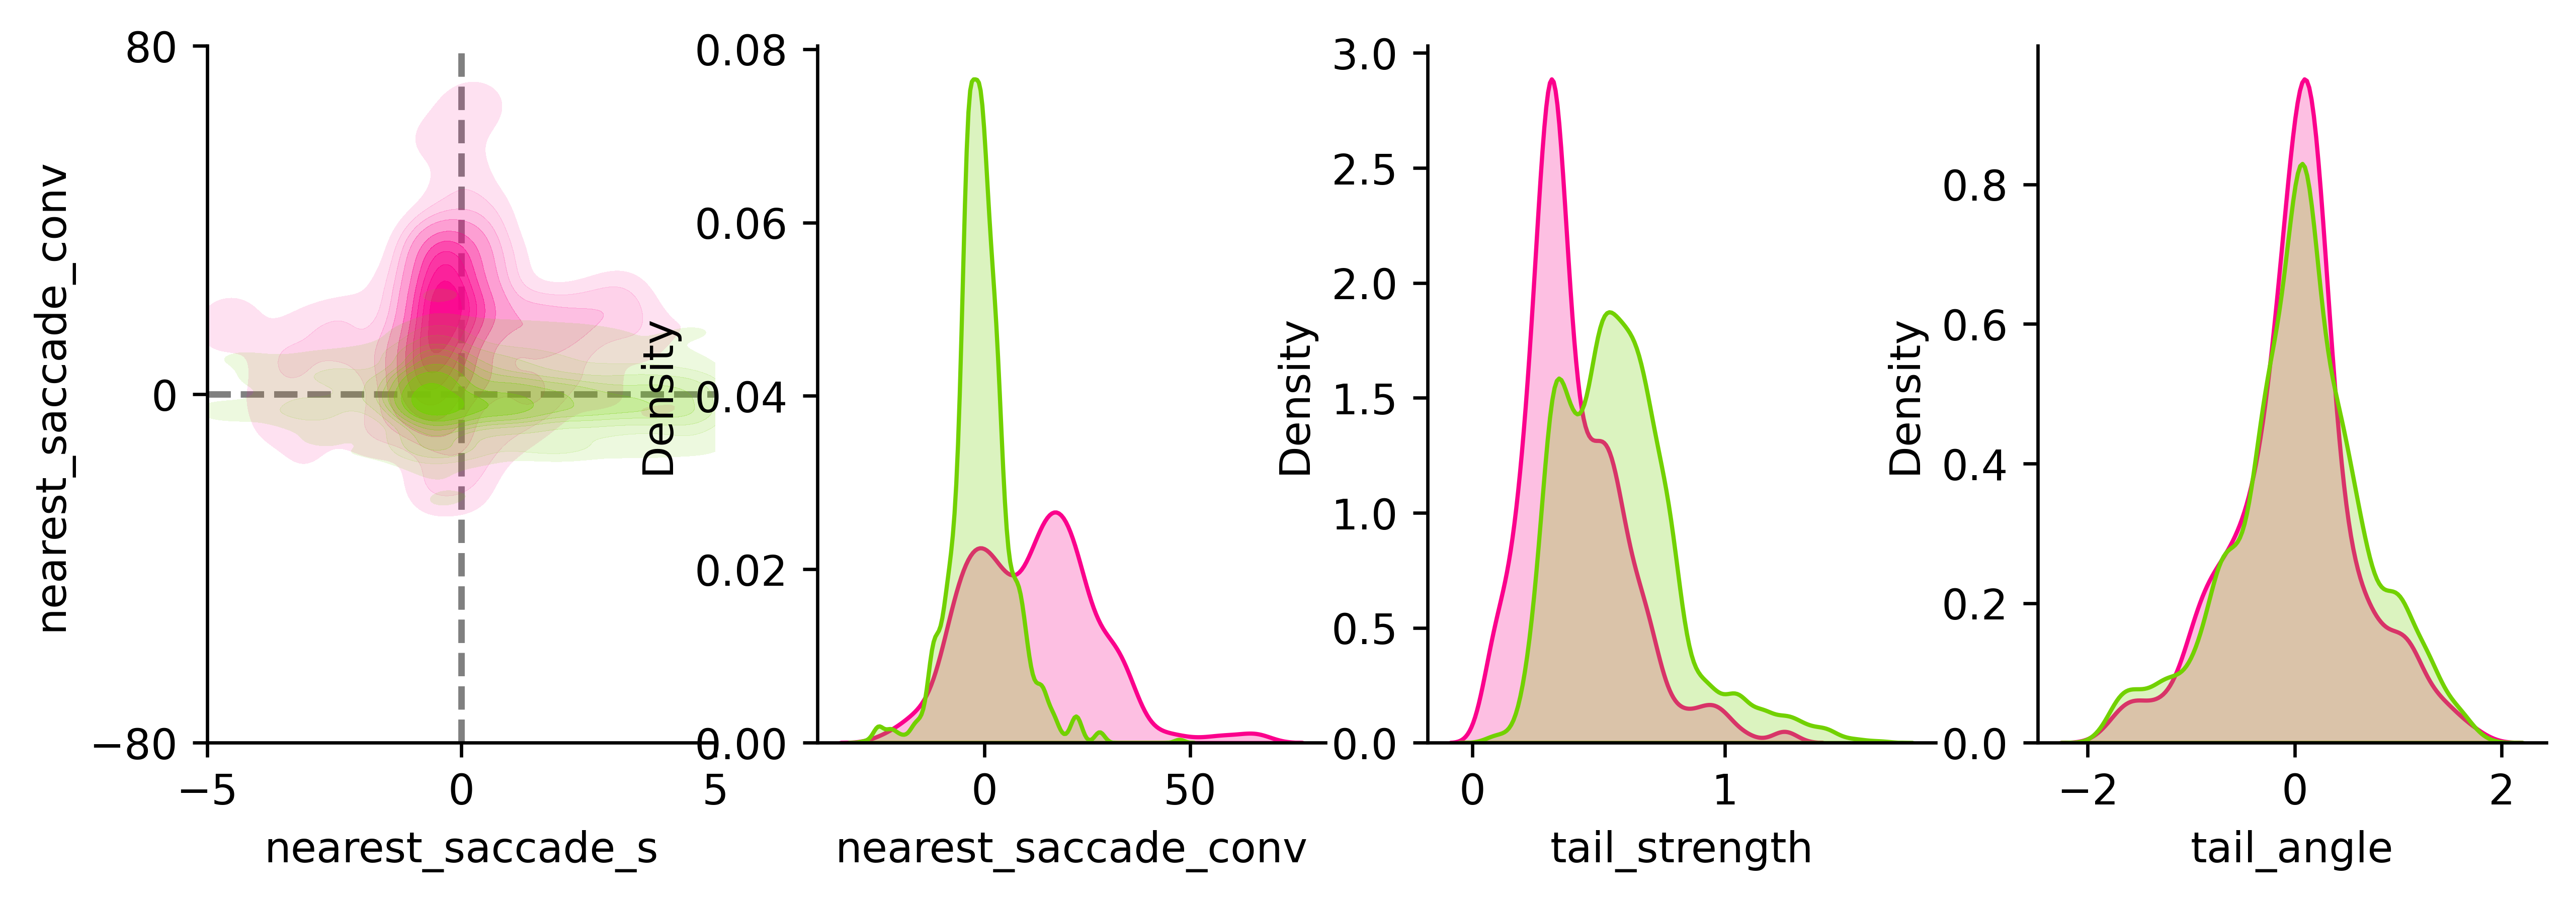

In [37]:
from scipy.interpolate import interp1d

# Recompute KDE values for both stimuli
from scipy.stats import gaussian_kde
def plot_feature_distribution_combined(dotstim, gratingstim, all_df):
    fig, ax = plt.subplots(1, 4, figsize = (10, 3), dpi = 600)
    for stim, stim_color in zip([dotstim, gratingstim], [pink, green]):
        df_interest = all_df[all_df.tail_realstimuli.isin(stim)]
        stim_color = mcolors.to_rgba(stim_color)
        stim_color = mcolors.to_rgba(stim_color)
        custom_cmap = LinearSegmentedColormap.from_list( 'stim_cmap', [(*stim_color[:3], 0.1),(*stim_color[:3], 0.7), (*stim_color[:3], 1) ])
        sns.kdeplot(x = df_interest.nearest_saccade_s, y =df_interest.nearest_saccade_conv, fill=True, cmap = custom_cmap, bw_adjust = .8, ax=ax[0])
        ax[0].set_ylim([-80, 80])
        ax[0].set_yticks([-80, 0, 80])
        ax[0].axhline(0, color='grey', linestyle='--', zorder = -1)
        ax[0].set_xlim([-5, 5])
        ax[0].set_xticks([-5, 0, 5])
        ax[0].axvline(0, color='grey', linestyle='--', zorder = -1)
        sns.kdeplot(x=df_interest.nearest_saccade_conv, fill=True, color = stim_color, bw_adjust = .8, ax=ax[1])
        sns.kdeplot(x=df_interest.tail_strength, fill=True, color = stim_color, bw_adjust = .8, ax=ax[2])
        sns.kdeplot(x=df_interest.tail_angle, fill=True, color = stim_color, bw_adjust = .8, ax=ax[3])
        # ax[0].set_xlabel('duration(s)')
        # ax[0].set_ylabel('convergence')
        # ax[1].set_xlabel('strength')
        # ax[1].set_ylabel('convergence')
        for axis in ax:
            axis.spines[['top', 'right']].set_visible(False)
        #get intersect
        x_grid = np.linspace(ax[1].get_xlim()[0], ax[1].get_xlim()[1], 1000)

        df_dot = all_df[all_df.tail_realstimuli.isin(dotstim)]
        df_grating = all_df[all_df.tail_realstimuli.isin(gratingstim)]

        kde_dot = gaussian_kde(df_dot.nearest_saccade_conv, bw_method=0.8 / df_dot.nearest_saccade_conv.std())
        kde_grating = gaussian_kde(df_grating.nearest_saccade_conv, bw_method=0.8 / df_grating.nearest_saccade_conv.std())

        diff = kde_dot(x_grid) - kde_grating(x_grid)
        sign_changes = np.where(np.diff(np.sign(diff)))[0]

        intersections = x_grid[sign_changes]
        print("Intersection(s) at x =", intersections)
    return fig
dotstim = ['dot_l', 'dot_r']
gratingstim = ['forward', 'left', 'right', 'backward']
plot_feature_distribution_combined(dotstim, gratingstim, all_df)
plt.savefig(path + 'tail_features_summary.svg')
plt.show()
plt.close()

__Get tail time series data__

In [9]:
#try to get the tail traces for all the fish
tail_collection = []
interesting_cols = [f"theta_{tail_seg}" if tail_seg >= 10 else f"theta_0{tail_seg}" for tail_seg in range(0, 13)]
frames = 150
for f in fishlist:
    bout_df = pd.read_csv(f + '//Tail//tail_bout_df.csv', index_col=0)
    bout_df.loc[:, "fish_id"] = f
    tail_df = pd.read_hdf(f + '//Tail//tail_df.hdf', index_col=0)
    for col in interesting_cols:
        tail_df.loc[:, col] = np.subtract(tail_df.loc[:, col], np.nanmean(tail_df.loc[:, col]))
    for _, bout_row in bout_df.iterrows():
        cont_tuples = eval(bout_row.cont_tuples_tailindex)
        cont_tuples = (cont_tuples[0], cont_tuples[0] + frames)
        tail_trace = tail_df.loc[cont_tuples[0]:cont_tuples[1], interesting_cols].reset_index(drop = True)
        if len(tail_trace) < frames:
            tail_trace = tail_trace.reindex(range(frames + 1))
        tail_collection.append(tail_trace)
tail_collection_arr = np.array(tail_collection)#index, frame, segment
tail_collection_arr = np.nan_to_num(tail_collection_arr)

In [10]:
bout_collection =  np.stack([df.to_numpy().ravel() for df in tail_collection],axis=0)
bout_collection = np.nan_to_num(bout_collection)
bout_feature_collection = all_df.drop(['cont_tuples_tailindex', 'cont_tuples_realtime_s', 'tail_stimuli', 'tail_realstimuli', 'tail_fromstart_s', 'fish_id'], axis = 1).reset_index(drop = True).fillna(0)

__More basic characterization__

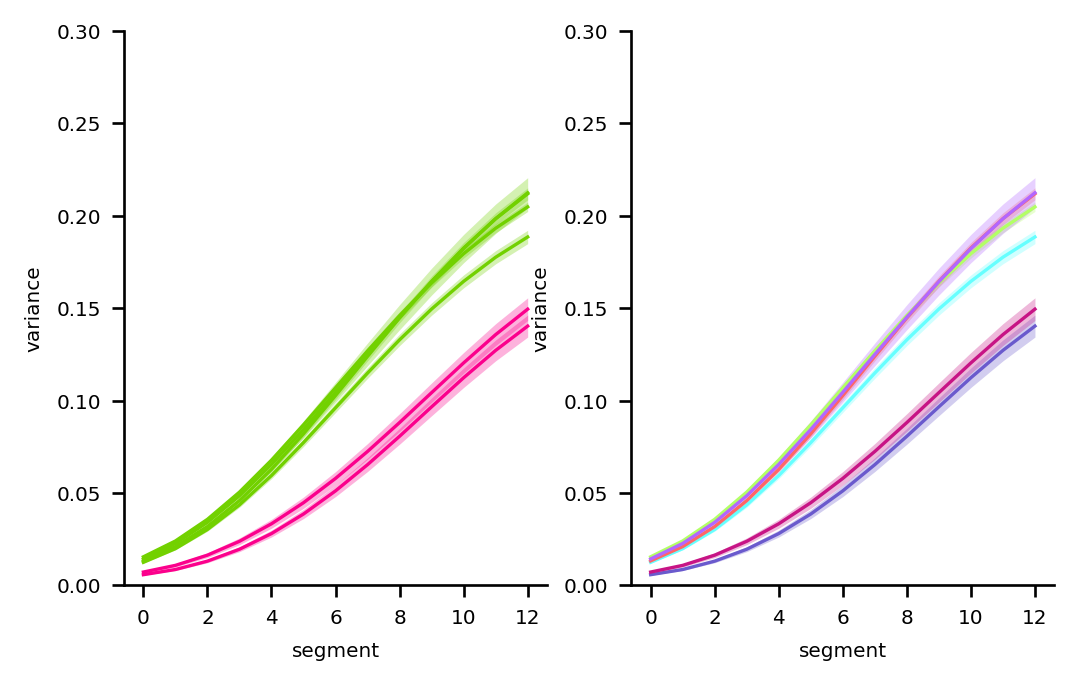

In [28]:
def plot_variances(all_df, tail_collection_arr, bystim = True, stimlist = None):
    fig, ax = plt.subplots(1, 2, dpi  = 240, figsize = (5, 3))
    if bystim:
        cs = [pink, pink, green, green, green, green]
        stimlist = ['dot_l', 'dot_r', 'forward', 'left', 'right', 'backward']
    else:
        cs = [pink, utils.stim_colors['left'], utils.stim_colors['right']]
    for n, stim in enumerate(stimlist):
        if bystim:
            bout_index = all_df[(all_df.tail_realstimuli == stim)].index
        else:
            bout_index = all_df[all_df.bout_type == stim].index
        #calculate variance for each segment
        var_perseg = np.std(tail_collection_arr[bout_index, :, :], axis = 1)
        mean_var = np.mean(var_perseg, axis=0)
        std_var = np.std(var_perseg, axis=0)
        sem_var = std_var / np.sqrt(var_perseg.shape[0])
        x = np.arange(mean_var.shape[0])
        ax[0].plot(x, mean_var, linewidth = 1, alpha = 1, color = cs[n])
        ax[0].fill_between(x, mean_var - sem_var,mean_var + sem_var,alpha=0.3, linewidth = 0, color = cs[n])
        if bystim:
            ax[1].plot(x, mean_var, linewidth = 1, alpha = 1, color = utils.stim_colors[stim])
            ax[1].fill_between(x, mean_var - sem_var,mean_var + sem_var,alpha=0.3, linewidth = 0, color = utils.stim_colors[stim])
    for axis in ax:
        axis.set_ylim([0, .3])
        axis.set_ylabel('variance')
        axis.set_xlabel('segment')
        axis.spines[['top', 'right']].set_visible(False)
    return fig
plot_variances(all_df, tail_collection_arr)
plt.savefig(path + 'segment_variance_summary.svg')
plt.show()
plt.close()

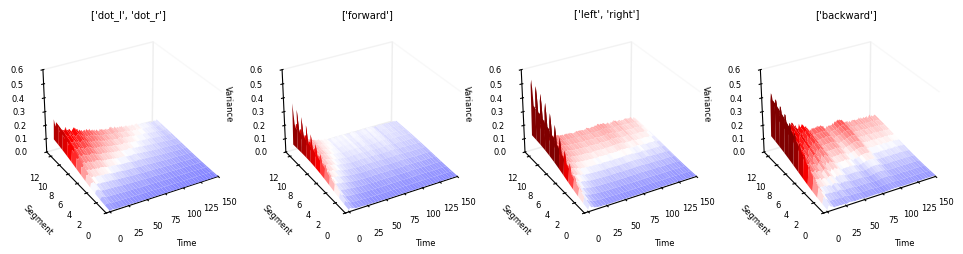

In [32]:
def plot_tail_traces(all_df, tail_collection_arr, bystim = True, stimlist = None):
    fig = plt.figure(figsize=(18, 12), dpi=100, facecolor='white')
    if bystim:
        stimlist = [['dot_l', 'dot_r'], ['forward'], ['left', 'right'], ['backward']]
    else:
        stimlist = stimlist

    for n, stim in enumerate(stimlist):
        if bystim:
            bout_index = all_df[(all_df.tail_realstimuli.isin(stim))].index
        else:
            bout_index = all_df[(all_df.bout_type == stim)].index
            # flip negative bouts
        traces = tail_collection_arr[bout_index, :, :]
        flip_mask = np.nanmean(traces[:, :, :], axis=(1, 2)) < 0
        traces[flip_mask] *= -1
        # variance across bouts
        # shape = (time, segment)
        var_map = np.nanmean(traces, axis=0)
        # axes
        time = np.arange(var_map.shape[0])
        segs = np.arange(var_map.shape[1])
        X, Y = np.meshgrid(time, segs, indexing='ij')
        ax = fig.add_subplot(1, 6, n + 1, projection='3d')
        surf = ax.plot_surface(
            X,
            Y,
            var_map,
            cmap='seismic', linewidth=0, antialiased=True, vmin =-0.15, vmax = 0.25)

        ax.set_title(stim)
        ax.set_xlabel('Time')
        ax.set_ylabel('Segment')
        ax.set_zlabel('Variance')
        ax.set_zlim([0, 0.6])
        ax.set_ylim([0, 13])
        ax.set_xlim([-5, 150])
        ax.view_init(elev=30, azim=60)
        ax.xaxis.pane.fill = False
        ax.yaxis.pane.fill = False
        ax.zaxis.pane.fill = False
        ax.invert_xaxis()
        ax.invert_yaxis()
        ax.grid(False)
    return fig
plot_tail_traces(all_df, tail_collection_arr)
plt.savefig(path + 'tail_collection.png')
plt.show()
plt.close()

__clustering 1: bout time series__

In [23]:
from openTSNE import TSNE as TSNE_fast
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


def bout_tsne_fast(bout_collection, kws = {'perplexity':10}):
    """
    Perform tsne on all the bouts
    """
    tsne = TSNE_fast(random_state=42, perplexity = kws['perplexity'], n_jobs=8)
    X_embedded = tsne.fit(bout_collection)
    return X_embedded

def bout_pca(bout_collection):
    """
    Perform tsne on all the bouts
    """
    x = StandardScaler().fit_transform(bout_collection)
    pca = PCA(n_components=5)
    X_embedded = pca.fit_transform(x)
    return X_embedded

X_embedded = bout_tsne_fast(bout_collection, kws = {'perplexity':10})
#X_embedded = bout_pca(bout_collection)

__clustering 2: bout features tsne__

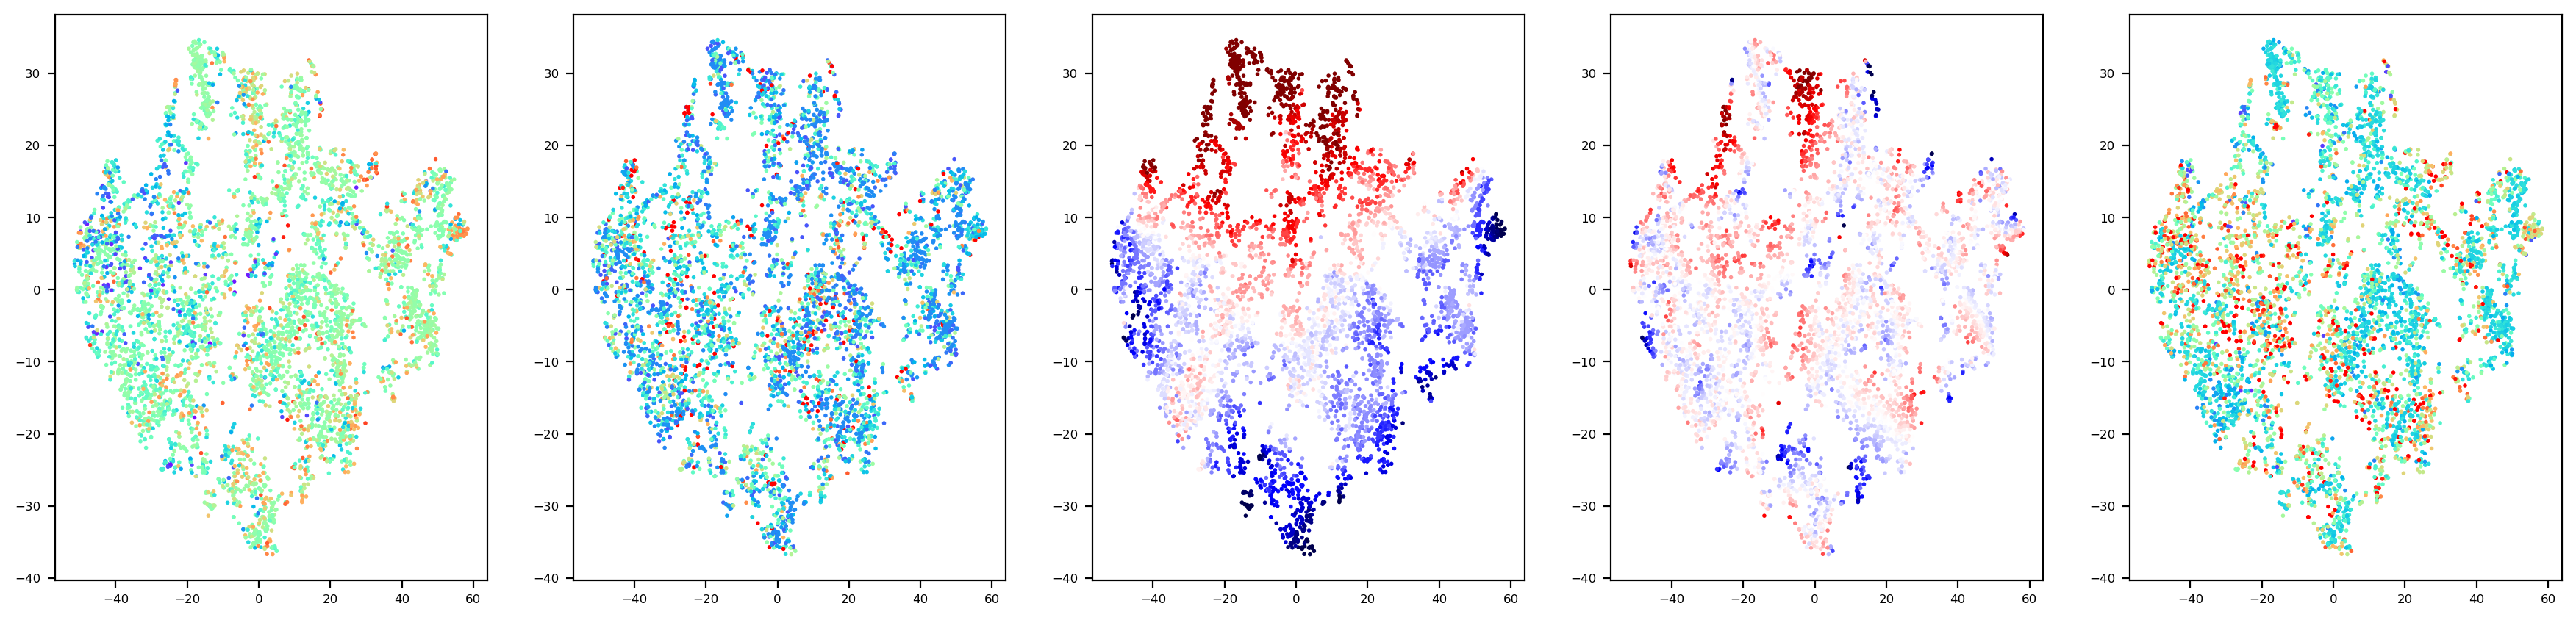

In [25]:

X_embedded = bout_tsne_fast(np.array(bout_feature_collection), kws={'perplexity': 100})
#X_embedded = bout_pca(np.array(bout_feature_collection))
fig, ax = plt.subplots(1, 5, figsize=(22, 5), dpi=200)
ax[0].scatter(X_embedded[:, 0], X_embedded[:, 1], s=1, cmap='rainbow', c=all_df.tail_angle, vmin=-2, vmax=2)
ax[1].scatter(X_embedded[:, 0], X_embedded[:, 1], s=1, cmap='rainbow', c=all_df.tail_duration_s, vmin=0, vmax=.5)
ax[2].scatter(X_embedded[:, 0], X_embedded[:, 1], s=1, cmap='seismic', c=all_df.nearest_saccade_conv, vmin=-20, vmax=20)
ax[3].scatter(X_embedded[:, 0], X_embedded[:,1], s=1, cmap='seismic', c=all_df.eye_vergence, vmin=-30, vmax=30)
ax[4].scatter(X_embedded[:, 0], X_embedded[:, 1], s=1, cmap='rainbow', c=all_df.tail_strength, vmin=0, vmax=1)

plt.show()
plt.close()

__clustering 3: K means + features__

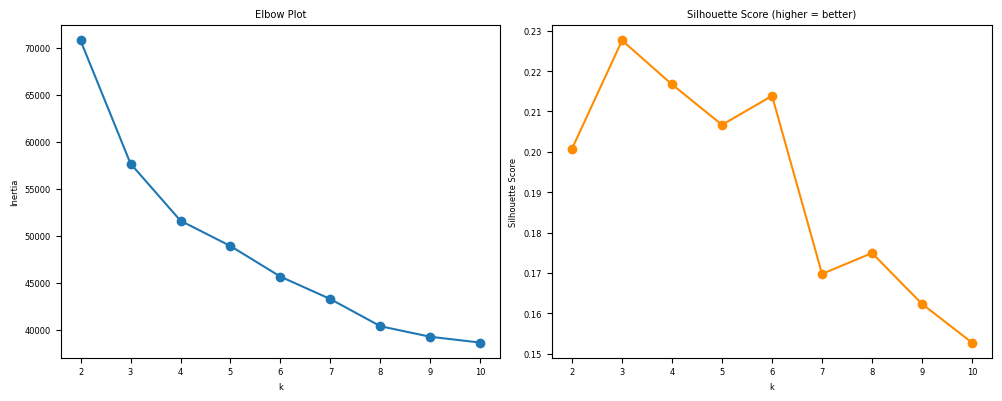

ValueError: Inspect the plots above and rerun with n_clusters=<your chosen k>.

In [13]:

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score


def cluster_bouts_kmeans(df: pd.DataFrame,n_clusters: int = None,k_range: range = range(2, 11),feature_cols: list = None,scale: bool = True,random_state: int = 42,) -> tuple[pd.DataFrame, KMeans, StandardScaler | None]:
    """
    Cluster bout_feature_collection rows using K-Means.

    Parameters
    ----------
    df : pd.DataFrame
        Your bout_feature_collection dataframe.
    n_clusters : int, optional
        Number of clusters. If None, runs elbow + silhouette plots
        so you can pick k, then raises an error prompting you to rerun with k set.
    k_range : range
        Range of k values to evaluate if n_clusters is None.
    feature_cols : list, optional
        Columns to use as features. Defaults to all numeric columns.
    scale : bool
        Whether to StandardScale features before clustering (recommended).
    random_state : int
        Random seed for reproducibility.

    Returns
    -------
    df_out : pd.DataFrame
        Copy of df with a 'cluster' column added.
    kmeans : KMeans
        Fitted KMeans object.
    scaler : StandardScaler or None
        Fitted scaler (use to transform new data), or None if scale=False.
    """
    # --- feature selection ---
    if feature_cols is None:
        feature_cols = df.select_dtypes(include=np.number).columns.tolist()

    X = df[feature_cols].copy()

    if X.isnull().any().any():
        raise ValueError(f"NaNs found in feature columns. Drop or impute before clustering.")

    # --- optional scaling ---
    scaler = None
    if scale:
        scaler = StandardScaler()
        X_fit = scaler.fit_transform(X)
    else:
        X_fit = X.values

    # --- k selection mode: plot elbow + silhouette and bail ---
    if n_clusters is None:
        inertias, sil_scores = [], []

        for k in k_range:
            km = KMeans(n_clusters=k, random_state=random_state, n_init="auto")
            labels = km.fit_predict(X_fit)
            inertias.append(km.inertia_)
            sil_scores.append(silhouette_score(X_fit, labels))

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

        ax1.plot(list(k_range), inertias, marker="o")
        ax1.set_xlabel("k")
        ax1.set_ylabel("Inertia")
        ax1.set_title("Elbow Plot")

        ax2.plot(list(k_range), sil_scores, marker="o", color="darkorange")
        ax2.set_xlabel("k")
        ax2.set_ylabel("Silhouette Score")
        ax2.set_title("Silhouette Score (higher = better)")

        plt.tight_layout()
        plt.show()

        raise ValueError("Inspect the plots above and rerun with n_clusters=<your chosen k>.")

    # --- fit final model ---
    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init="auto")
    labels = kmeans.fit_predict(X_fit)

    sil = silhouette_score(X_fit, labels)
    print(f"K-Means fit: k={n_clusters}, silhouette={sil:.3f}")
    print(f"Cluster sizes:\n{pd.Series(labels).value_counts().sort_index().to_string()}")

    df_out = df.copy()
    df_out["cluster"] = labels

    return df_out, kmeans, scaler
# Step 1 — run without k to see elbow/silhouette plots
cluster_bouts_kmeans(bout_feature_collection)


In [14]:
cluster = 3
# Step 2 — pick k from the plots, rerun
df_clustered, kmeans, scaler = cluster_bouts_kmeans(
    bout_feature_collection.loc[:, ['tail_strength',  'tail_duration_s', 'nearest_saccade_conv']],
    n_clusters=cluster  # your chosen k
)

K-Means fit: k=3, silhouette=0.327
Cluster sizes:
0    3731
1    1036
2    2339


In [28]:
bout_feature_collection.loc[:, "cluster"]=df_clustered.cluster

C:\Users\Zichen\anaconda3\envs\2ptank\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


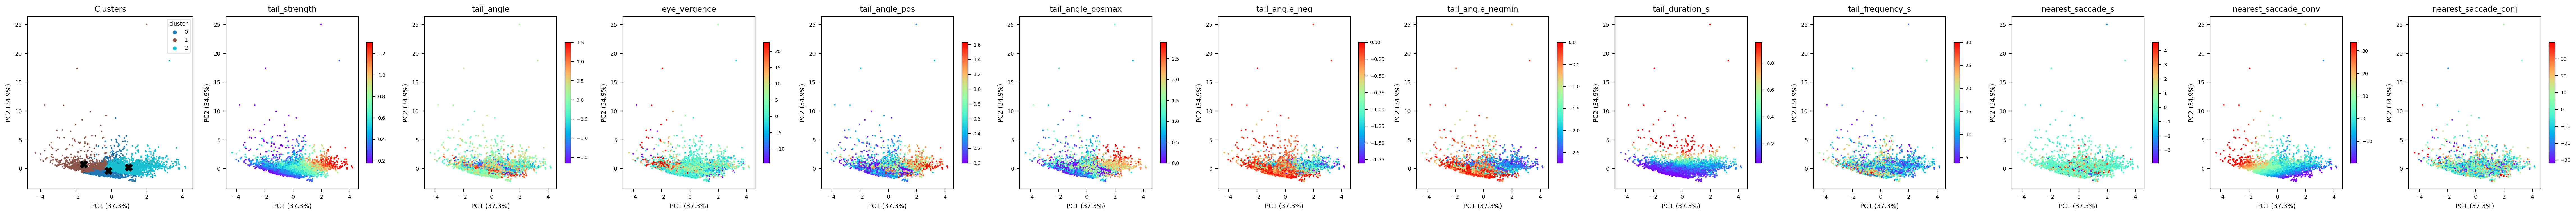

In [15]:
def plot_kmeans_pca_features(df_clustered: pd.DataFrame,bout_feature_collection:pd.DataFrame, kmeans: KMeans,scaler: StandardScaler | None,feature_cols: list = None,):
    from sklearn.decomposition import PCA

    if feature_cols is None:
        feature_cols = bout_feature_collection.select_dtypes(include=np.number).columns.tolist()
        feature_cols = [c for c in feature_cols if c != "cluster"]

    n_panels =len(feature_cols) + 1

    X = df_clustered.iloc[:, :-1].values
    X_scaled = scaler.transform(X) if scaler is not None else X

    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_scaled)
    centroids_pca = pca.transform(kmeans.cluster_centers_)
    var1, var2 = pca.explained_variance_ratio_ * 100

    vlims = [(np.percentile(bout_feature_collection[f], 1), np.percentile(bout_feature_collection[f], 99))
            for f in feature_cols]

    fig, axes = plt.subplots(1, n_panels, figsize=(4.5 * n_panels, 4), dpi=200)
    # --- cluster panel ---
    ax = axes[0]
    ax_offset = 1
    labels = df_clustered["cluster"].values
    n_clusters = kmeans.n_clusters
    cmap_clust = plt.get_cmap("tab10", n_clusters)

    for k in range(n_clusters):
        mask = labels == k
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],s=1, c=[cmap_clust(k)], label=f"{k}",)
        ax.scatter(centroids_pca[:, 0], centroids_pca[:, 1],c="black", marker="X", s=80, zorder=5,)
        ax.set_title("Clusters", fontsize=10)
        ax.set_xlabel(f"PC1 ({var1:.1f}%)", fontsize=8)
        ax.set_ylabel(f"PC2 ({var2:.1f}%)", fontsize=8)
        ax.tick_params(labelsize=7)
        ax.legend(markerscale=4, fontsize=7, title="cluster",
                  title_fontsize=7, framealpha=0.6)

    # --- feature panels ---
    for i, (feat, (vmin, vmax)) in enumerate(zip(feature_cols, vlims)):
        ax = axes[i + ax_offset]
        sc = ax.scatter(X_pca[:, 0], X_pca[:, 1],s=1, c=bout_feature_collection[feat],
            cmap='rainbow', vmin=vmin, vmax=vmax,)
        ax.set_title(feat, fontsize=10)
        ax.set_xlabel(f"PC1 ({var1:.1f}%)", fontsize=8)
        ax.set_ylabel(f"PC2 ({var2:.1f}%)", fontsize=8)
        ax.tick_params(labelsize=7)
        plt.colorbar(sc, ax=ax, shrink=0.7)

    plt.show()
plot_kmeans_pca_features(df_clustered, bout_feature_collection, kmeans, scaler)


In [25]:
#asslign clusters
all_df.loc[:, "bout_type"] = [
    'H' if c == 1 else ('R' if row['tail_angle'] >= 0 else 'L')
    for c, (_, row) in zip(df_clustered["cluster"], all_df.iterrows())]

__lets try supervised...__

In [1]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def train_svm_and_classify(
    grating_df: pd.DataFrame,
    dot_df: pd.DataFrame,
    target_df: pd.DataFrame,
    feature_cols: list = None,
    kernel: str = "rbf",
    C: float = 1.0,
    gamma: str = "scale",
    random_state: int = 42,
) -> tuple[pd.DataFrame, SVC, StandardScaler]:
    """
    Train an SVM on grating and dot bout features, then classify target_df.

    Parameters
    ----------
    grating_df : pd.DataFrame
        Training data labeled 'grating'.
    dot_df : pd.DataFrame
        Training data labeled 'dot'.
    target_df : pd.DataFrame
        bout_feature_collection to classify.
    feature_cols : list, optional
        Features to use. Defaults to all numeric columns shared across all three dfs.
    kernel : str
        SVM kernel: 'rbf', 'linear', 'poly', 'sigmoid'.
    C : float
        Regularization parameter. Higher = less regularization.
    gamma : str or float
        Kernel coefficient for 'rbf'/'poly'/'sigmoid'.
    random_state : int
        For reproducibility.

    Returns
    -------
    df_out : pd.DataFrame
        Copy of target_df with 'stimulus_type' column added.
    svm : SVC
        Fitted SVM classifier.
    scaler : StandardScaler
        Fitted scaler (use to transform new data).
    """
    # --- feature selection ---
    if feature_cols is None:
        numeric_cols = lambda df: set(df.select_dtypes(include=np.number).columns)
        feature_cols = list(numeric_cols(grating_df) & numeric_cols(dot_df) & numeric_cols(target_df))

    # --- build training set ---
    X_grating = grating_df[feature_cols].copy()
    X_dot = dot_df[feature_cols].copy()

    X_train = pd.concat([X_grating, X_dot], axis=0).reset_index(drop=True)
    y_train = np.array(["grating"] * len(X_grating) + ["dot"] * len(X_dot))

    if X_train.isnull().any().any():
        raise ValueError("NaNs found in training features. Drop or impute before fitting.")

    # --- scale ---
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)

    # --- fit ---
    svm = SVC(kernel=kernel, C=C, gamma=gamma, random_state=random_state, probability=True, class_weight='balanced')
    svm.fit(X_train_scaled, y_train)

    # --- training performance ---
    y_pred_train = svm.predict(X_train_scaled)
    print("=== Training set performance ===")
    print(classification_report(y_train, y_pred_train))

    fig, ax = plt.subplots(figsize=(4, 3), dpi=150)
    ConfusionMatrixDisplay.from_predictions(y_train, y_pred_train, ax=ax)
    ax.set_title("Confusion Matrix (training set)")
    plt.tight_layout()
    plt.show()

    # --- classify target ---
    X_target = target_df[feature_cols].copy()
    if X_target.isnull().any().any():
        raise ValueError("NaNs found in target features. Drop or impute before predicting.")

    X_target_scaled = scaler.transform(X_target)
    predictions = svm.predict(X_target_scaled)
    probabilities = svm.predict_proba(X_target_scaled)

    df_out = target_df.copy()
    df_out["bout_type"] = predictions
    df_out["prob_grating"] = probabilities[:, list(svm.classes_).index("grating")]
    df_out["prob_dot"] = probabilities[:, list(svm.classes_).index("dot")]

    print(f"\n=== Classification results (n={len(df_out)}) ===")
    print(df_out["bout_type"].value_counts().to_string())

    return df_out, svm, scaler
df_out, svm, scaler = train_svm_and_classify(pd.DataFrame(grating_collection), pd.DataFrame(dot_collection), pd.DataFrame(bout_feature_collection), ['tail_strength', 'tail_angle', 'eye_vergence', 'tail_angle_pos',
       'tail_angle_posmax', 'tail_angle_neg', 'tail_angle_negmin',
       'tail_duration_s', 'tail_frequency_s', 'nearest_saccade_s',
       'nearest_saccade_conv', 'nearest_saccade_conj']
                                             )

NameError: name 'grating_collection' is not defined

In [48]:
all_df.bout_type = df_out.bout_type

In [18]:
bout_feature_collection.columns

Index(['tail_strength', 'tail_angle', 'eye_vergence', 'tail_angle_pos',
       'tail_angle_posmax', 'tail_angle_neg', 'tail_angle_negmin',
       'tail_duration_s', 'tail_frequency_s', 'nearest_saccade_s',
       'nearest_saccade_conv', 'nearest_saccade_conj'],
      dtype='object')

In [40]:
dot_collection = bout_feature_collection[(all_df.tail_realstimuli.isin(['dot_l', 'dot_r'])) &(all_df.tail_fromstart_s >= 27) &(all_df.tail_fromstart_s <= 33)]
grating_collection = bout_feature_collection[all_df.tail_realstimuli.isin(['forward', 'left', 'right', 'backward'])]

__plot more features__

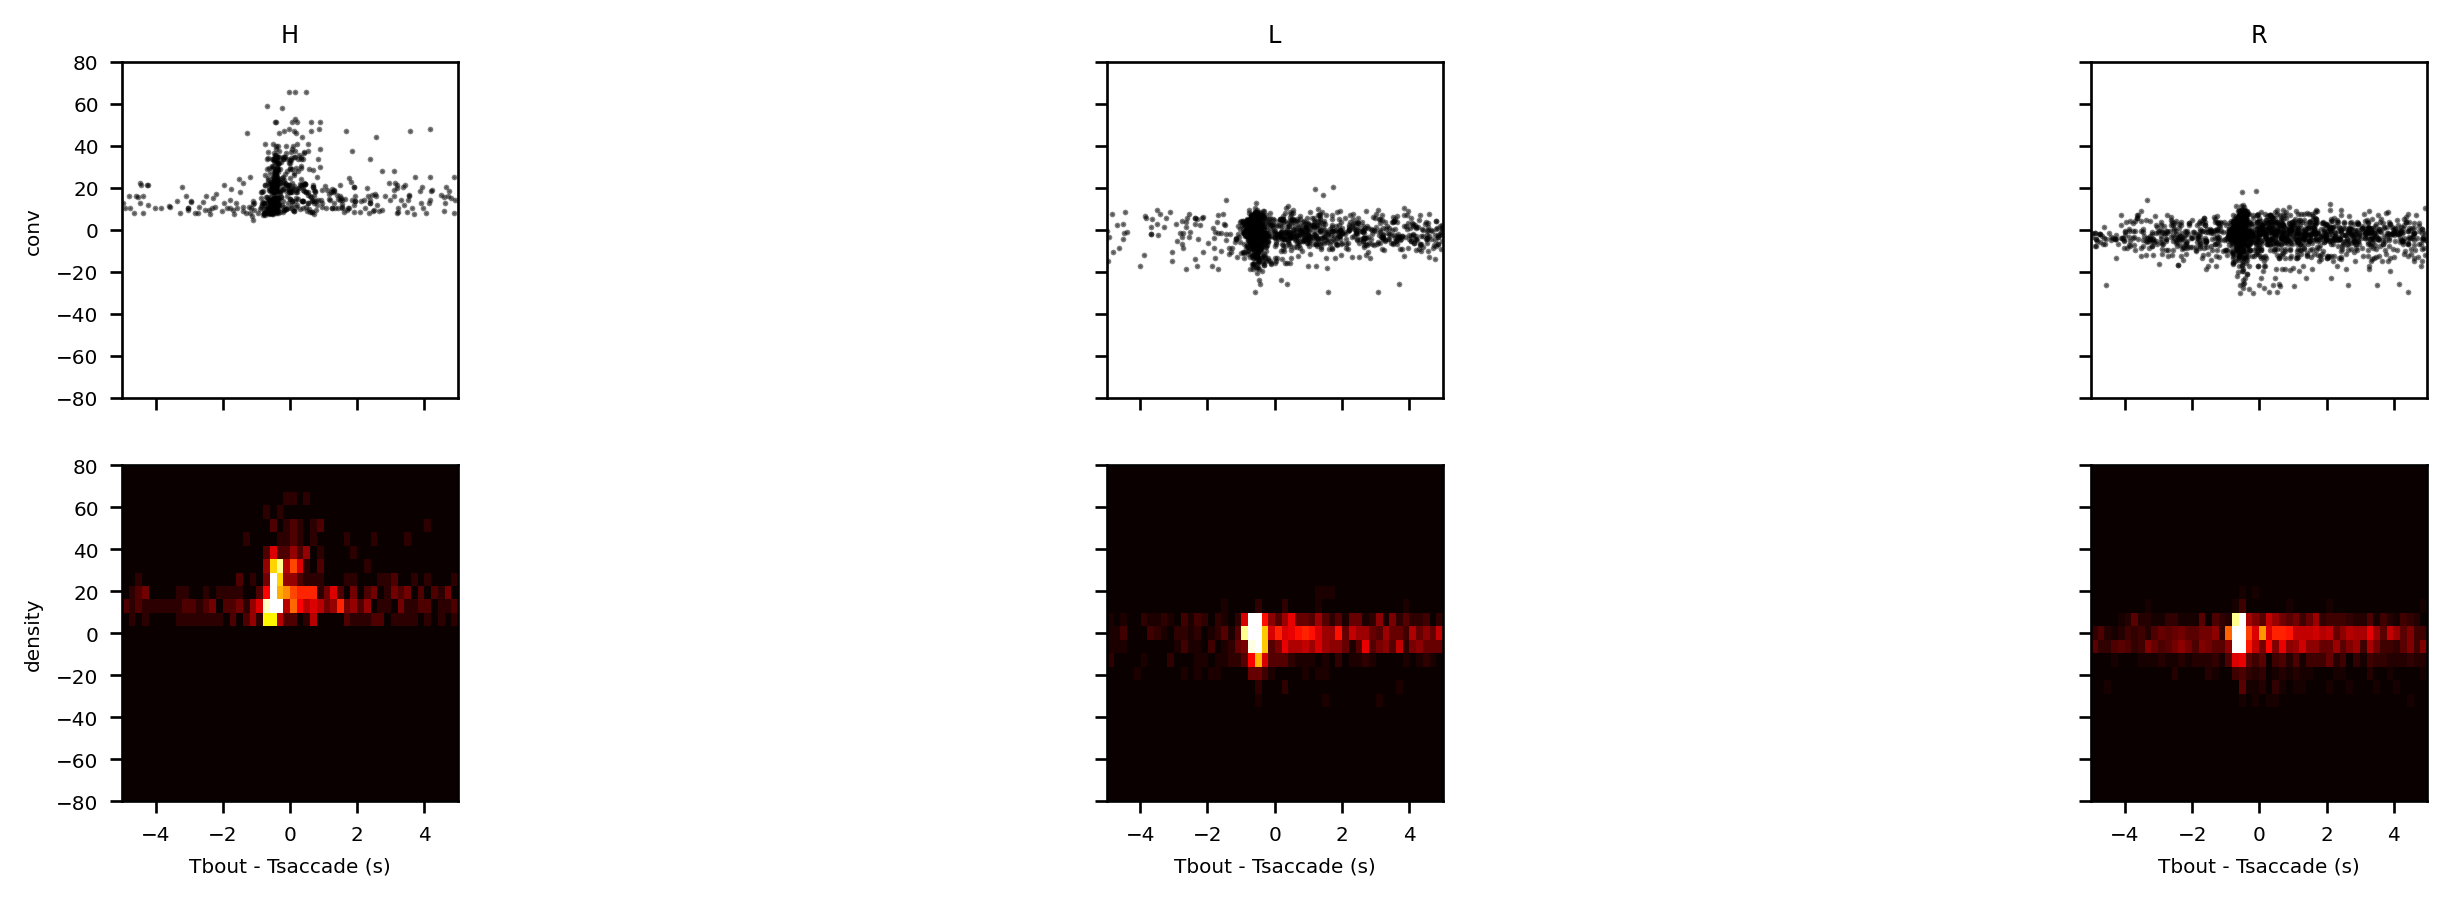

In [26]:
stims = ['H', 'L', 'R']
plot_nearest_saccade(stims, all_df, bystim=False)
plt.savefig(path + 'cluster_nearest_saccade_vergence.svg')
plt.show()
plt.close()

(0.984313725490196, 0.0, 0.5490196078431373) <class 'tuple'>
(0.3999999999999999, 0.9999999999999999, 1.0, 1) <class 'tuple'>
(1.0, 0.3999999999999999, 0.3999999999999999, 1) <class 'tuple'>


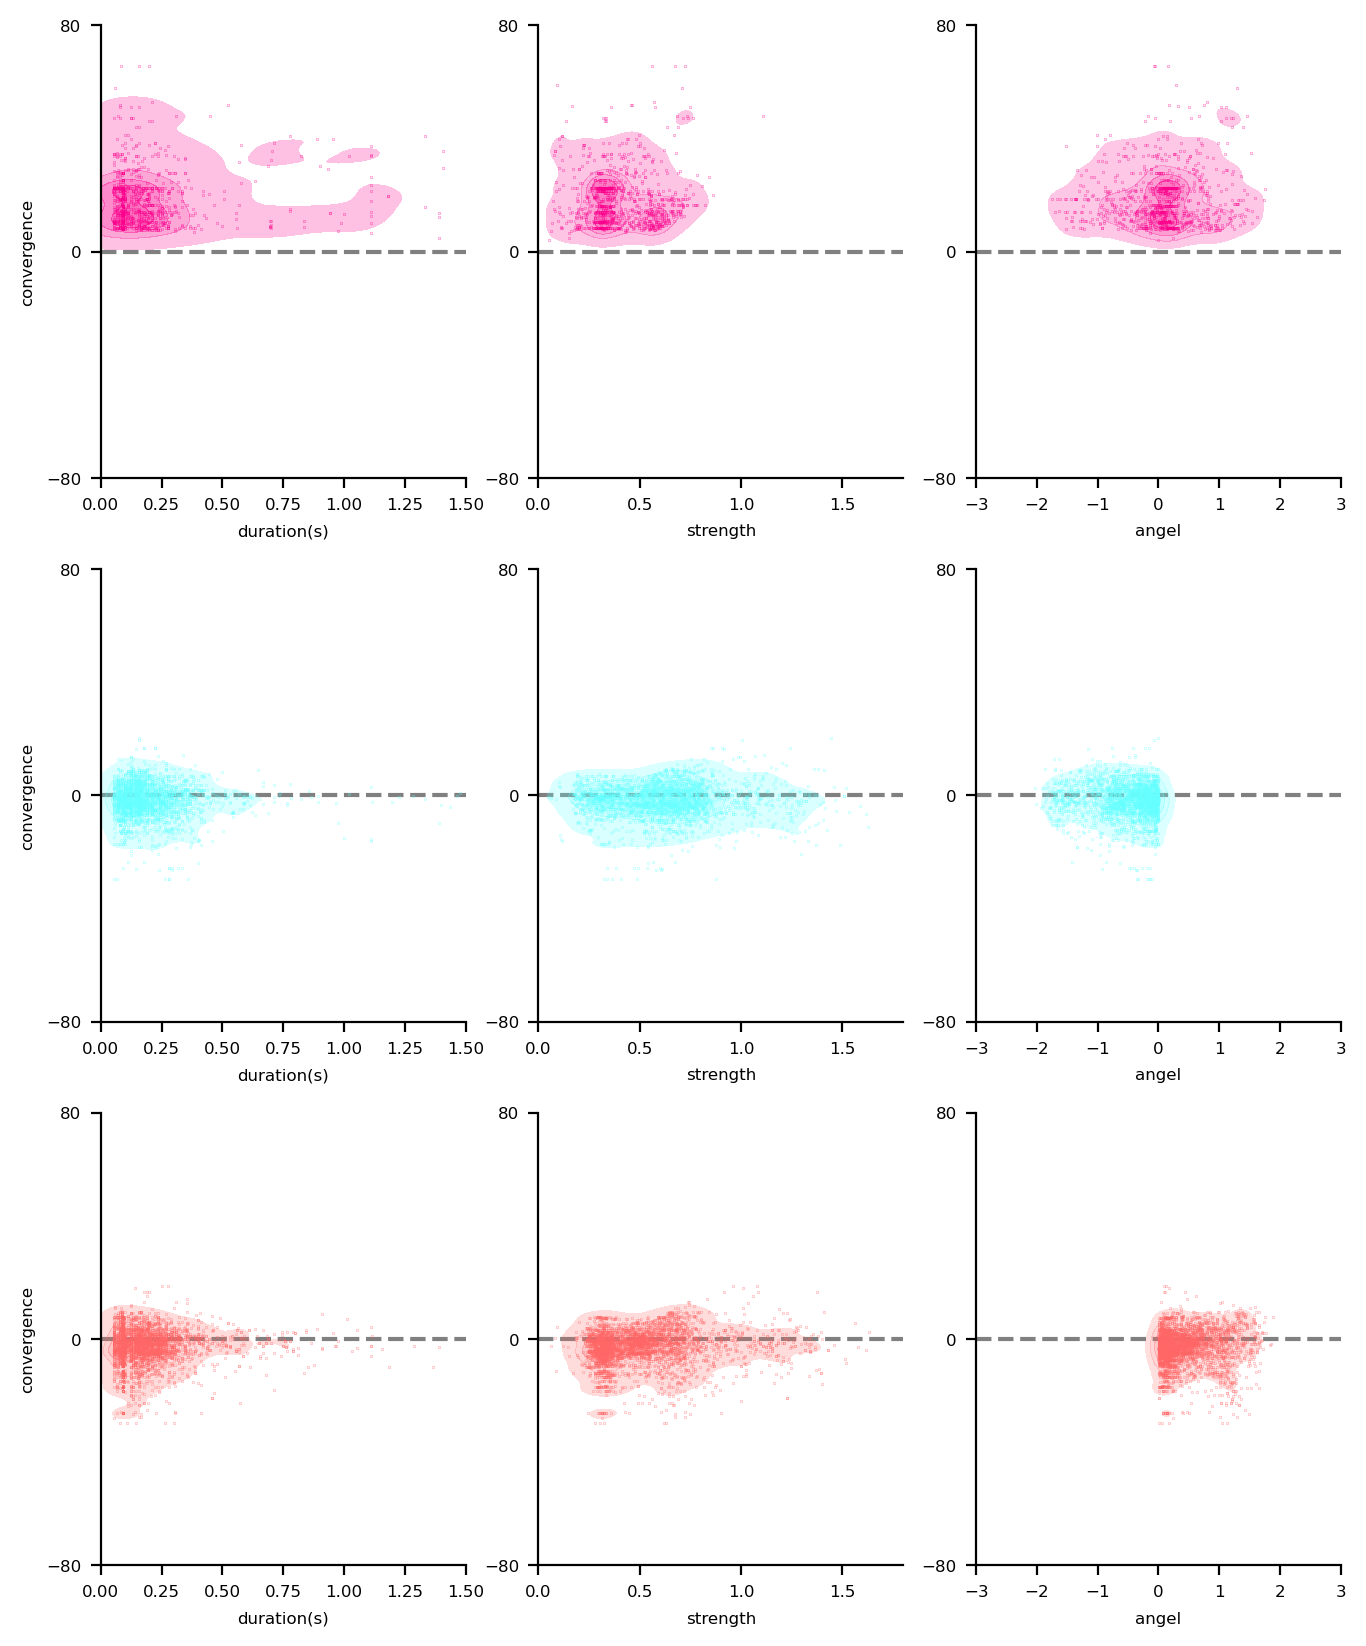

In [27]:
plot_feature_distribution(stims, all_df, bystim = False)
plt.savefig(path + 'cluster_tail_features.png')
plt.show()
plt.close()

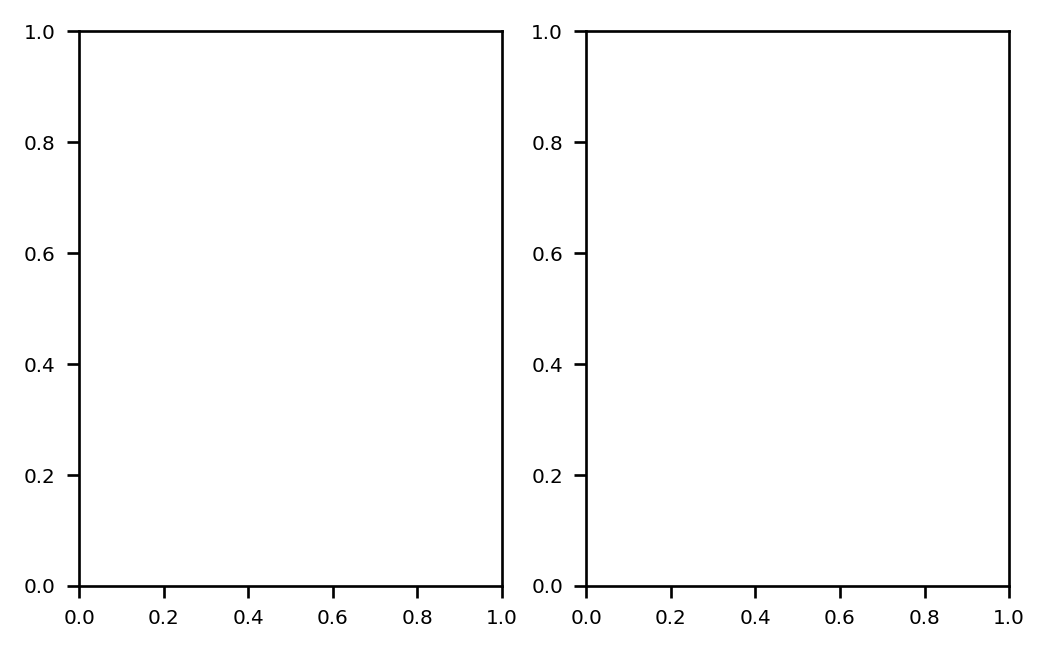

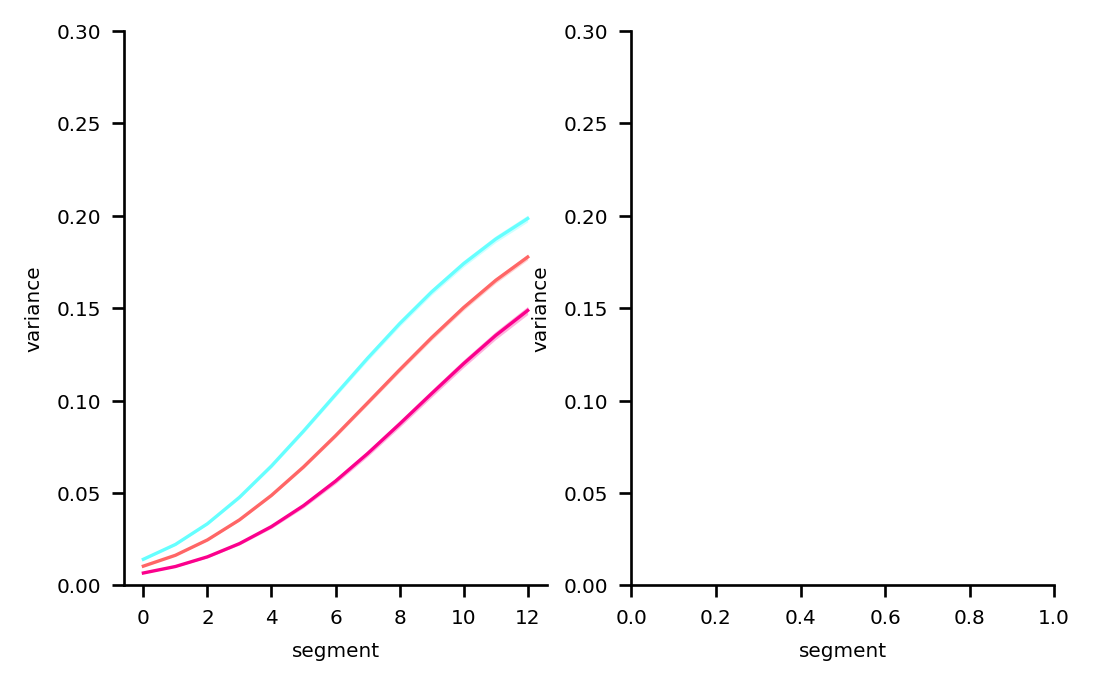

<Figure size 640x480 with 0 Axes>

In [30]:
plot_variances(all_df, tail_collection_arr, bystim = False, stimlist = stims)
plt.savefig(path + 'cluster_tail_variances.png')
plt.show()
plt.savefig(path + 'cluster_segment_variance_summary.svg')
plt.show()
plt.close()

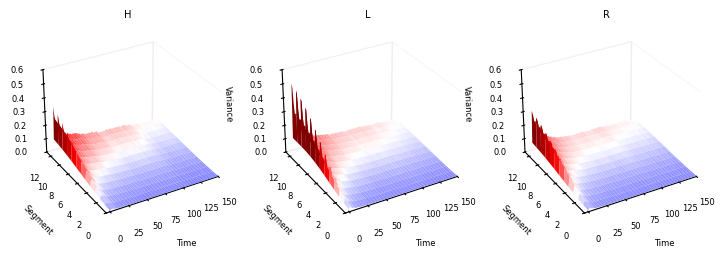

In [33]:
plot_tail_traces(all_df, tail_collection_arr, bystim = False, stimlist = stims)
plt.savefig(path + 'cluster_tail_collection.png')
plt.show()
plt.close()

In [23]:
all_df[all_df.bout_type == 'dot'].tail_realstimuli.value_counts()

tail_realstimuli
stationary               231
pause                    202
dot_l                    100
dot_r                     92
forward                   65
right                     61
backward                  42
['dot_l', 'backward']     41
left                      40
['dot_l', 'right']        39
['dot_r', 'left']         29
['dot_r', 'backward']     25
['dot_l', 'forward']      23
['dot_r', 'right']        21
['dot_l', 'left']         15
['dot_r', 'forward']      10
Name: count, dtype: int64

In [34]:
#assuming i trust this, let's put it within individual fish
for fish in all_df.fish_id.unique():
    fish_df = all_df[all_df.fish_id == fish]
    fish_df.to_csv(fish + '//tail//tail_bout_df_classified.csv')